In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('catastrophes_naturelles_parseable.csv')
df.head(15)

,Unnamed: 0,temperature,humidite,force_moyenne_du_vecteur_de_vent,force_du_vecteur_de_vent_max,pluie_intensite_max,date,quartier,sismicite,concentration_gaz,pluie_totale,catastrophe
0,0,5.7,75.6,3.8,4.3,0.0,2170-01-01,Zone 1,0.62,231.56,182.37,aucun
1,1,5.7,75.6,3.8,4.3,0.0,2170-01-01,Zone 2,0.94,248.20,903.20,['seisme']
2,2,5.7,75.6,3.8,4.3,0.0,2170-01-01,Zone 3,0.95,240.55,363.06,['seisme']
3,3,5.7,75.6,3.8,4.3,0.0,2170-01-01,Zone 4,0.39,159.10,473.93,aucun
4,4,5.7,75.6,3.8,4.3,0.0,2170-01-01,Zone 5,0.41,143.29,475.72,['innondation']
5,5,19.8,77.8,2.3,0.6,0.0,2171-01-01,Zone 1,0.66,276.74,605.97,['seisme']
6,6,19.8,77.8,2.3,0.6,0.0,2171-01-01,Zone 2,0.54,182.07,84.19,['innondation']
7,7,19.8,77.8,2.3,0.6,0.0,2171-01-01,Zone 3,0.74,177.30,161.78,aucun
8,8,19.8,77.8,2.3,0.6,0.0,2171-01-01,Zone 4,0.37,175.44,103.57,aucun
9,9,19.8,77.8,2.3,0.6,0.0,2171-01-01,Zone 5,0.50,127.11,560.36,aucun


In [3]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [4]:
df

,temperature,humidite,force_moyenne_du_vecteur_de_vent,force_du_vecteur_de_vent_max,pluie_intensite_max,date,quartier,sismicite,concentration_gaz,pluie_totale,catastrophe
0,5.7,75.6,3.8,4.3,0.0,2170-01-01,Zone 1,0.62,231.56,182.37,aucun
1,5.7,75.6,3.8,4.3,0.0,2170-01-01,Zone 2,0.94,248.20,903.20,['seisme']
2,5.7,75.6,3.8,4.3,0.0,2170-01-01,Zone 3,0.95,240.55,363.06,['seisme']
3,5.7,75.6,3.8,4.3,0.0,2170-01-01,Zone 4,0.39,159.10,473.93,aucun
4,5.7,75.6,3.8,4.3,0.0,2170-01-01,Zone 5,0.41,143.29,475.72,['innondation']
...,...,...,...,...,...,...,...,...,...,...,...
3390,27.4,46.8,3.8,6.3,0.0,2171-09-09,Zone 1,0.86,184.18,63.64,aucun
3391,27.4,46.8,3.8,6.3,0.0,2171-09-09,Zone 2,0.74,227.11,874.81,[''innondation'; 'seisme']
3392,27.4,46.8,3.8,6.3,0.0,2171-09-09,Zone 3,0.53,204.04,668.92,aucun
3393,27.4,46.8,3.8,6.3,0.0,2171-09-09,Zone 4,0.42,182.63,660.69,['innondation']


In [5]:
# 2. Conversion de la colonne 'date' en datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")


In [6]:
# 3. Supprimer les lignes avec des valeurs manquantes
df_cleaned = df.dropna()

In [7]:
df_cleaned

,temperature,humidite,force_moyenne_du_vecteur_de_vent,force_du_vecteur_de_vent_max,pluie_intensite_max,date,quartier,sismicite,concentration_gaz,pluie_totale,catastrophe
0,5.7,75.6,3.8,4.3,0.0,2170-01-01,Zone 1,0.62,231.56,182.37,aucun
1,5.7,75.6,3.8,4.3,0.0,2170-01-01,Zone 2,0.94,248.20,903.20,['seisme']
2,5.7,75.6,3.8,4.3,0.0,2170-01-01,Zone 3,0.95,240.55,363.06,['seisme']
3,5.7,75.6,3.8,4.3,0.0,2170-01-01,Zone 4,0.39,159.10,473.93,aucun
4,5.7,75.6,3.8,4.3,0.0,2170-01-01,Zone 5,0.41,143.29,475.72,['innondation']
...,...,...,...,...,...,...,...,...,...,...,...
3390,27.4,46.8,3.8,6.3,0.0,2171-09-09,Zone 1,0.86,184.18,63.64,aucun
3391,27.4,46.8,3.8,6.3,0.0,2171-09-09,Zone 2,0.74,227.11,874.81,[''innondation'; 'seisme']
3392,27.4,46.8,3.8,6.3,0.0,2171-09-09,Zone 3,0.53,204.04,668.92,aucun
3393,27.4,46.8,3.8,6.3,0.0,2171-09-09,Zone 4,0.42,182.63,660.69,['innondation']


In [ ]:
# import ast

# def clean_catastrophe(val):
#     if pd.isna(val) or str(val).strip() == "":
#         return "aucun"

#     val = str(val).replace(';', ',')  # corriger les séparateurs s'il y en a

#     try:
#         # Essayer de parser la chaîne en liste Python
#         parsed = ast.literal_eval(val)
#         if isinstance(parsed, list) and parsed:
#             return ", ".join(item.strip("'\" ") for item in parsed)
#         elif isinstance(parsed, list):
#             return "aucun"
#         else:
#             return val.strip()
#     except:
#         # Si parsing échoue mais que le champ contient un mot comme seisme ou innondation
#         if any(mot in val.lower() for mot in ["seisme", "inondation", "innondation", "tempête", "cyclone"]):
#             return val.strip()
#         return "aucun"


In [ ]:
import pandas as pd
import ast

def clean_catastrophe(val):
    if pd.isna(val) or str(val).strip() == "":
        return "aucun"
    
    val = str(val).replace(';', ',')  # corriger les séparateurs cassés
    val = val.replace('"', "'")       # uniformiser les guillemets
    
    try:
        # Essayer de parser la liste
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list) and parsed:
            # Supprimer guillemets, crochets, etc. → format texte concaténé avec espace
            return " ".join(item.strip("'\" ") for item in parsed)
        elif isinstance(parsed, list):
            return "aucun"
    except:
        # Si parsing échoue, mais contient des mots-clés : nettoyer quand même
        if any(mot in val.lower() for mot in ["seisme", "inondation", "innondation", "tempête", "cyclone"]):
            # Supprimer crochets et guillemets et séparer par espace
            propre = (
                val.replace("[", "")
                   .replace("]", "")
                   .replace("'", "")
                   .replace('"', "")
                   .replace(",", " ")
                   .replace(";", " ")
                   .strip()
            )
            return propre
        return "aucun"

# Appliquer au DataFrame
df_cleaned = df.copy()
df_cleaned["catastrophe"] = df_cleaned["catastrophe"].apply(clean_catastrophe)


In [9]:
df_cleaned

,temperature,humidite,force_moyenne_du_vecteur_de_vent,force_du_vecteur_de_vent_max,pluie_intensite_max,date,quartier,sismicite,concentration_gaz,pluie_totale,catastrophe
0,5.7,75.6,3.8,4.3,0.0,2170-01-01,Zone 1,0.62,231.56,182.37,aucun
1,5.7,75.6,3.8,4.3,0.0,2170-01-01,Zone 2,0.94,248.20,903.20,seisme
2,5.7,75.6,3.8,4.3,0.0,2170-01-01,Zone 3,0.95,240.55,363.06,seisme
3,5.7,75.6,3.8,4.3,0.0,2170-01-01,Zone 4,0.39,159.10,473.93,aucun
4,5.7,75.6,3.8,4.3,0.0,2170-01-01,Zone 5,0.41,143.29,475.72,innondation
...,...,...,...,...,...,...,...,...,...,...,...
3390,27.4,46.8,3.8,6.3,0.0,2171-09-09,Zone 1,0.86,184.18,63.64,aucun
3391,27.4,46.8,3.8,6.3,0.0,2171-09-09,Zone 2,0.74,227.11,874.81,innondation seisme
3392,27.4,46.8,3.8,6.3,0.0,2171-09-09,Zone 3,0.53,204.04,668.92,aucun
3393,27.4,46.8,3.8,6.3,0.0,2171-09-09,Zone 4,0.42,182.63,660.69,innondation


In [10]:
df_cleaned = df_cleaned.dropna()

In [11]:
df_cleaned

,temperature,humidite,force_moyenne_du_vecteur_de_vent,force_du_vecteur_de_vent_max,pluie_intensite_max,date,quartier,sismicite,concentration_gaz,pluie_totale,catastrophe
0,5.7,75.6,3.8,4.3,0.0,2170-01-01,Zone 1,0.62,231.56,182.37,aucun
1,5.7,75.6,3.8,4.3,0.0,2170-01-01,Zone 2,0.94,248.20,903.20,seisme
2,5.7,75.6,3.8,4.3,0.0,2170-01-01,Zone 3,0.95,240.55,363.06,seisme
3,5.7,75.6,3.8,4.3,0.0,2170-01-01,Zone 4,0.39,159.10,473.93,aucun
4,5.7,75.6,3.8,4.3,0.0,2170-01-01,Zone 5,0.41,143.29,475.72,innondation
...,...,...,...,...,...,...,...,...,...,...,...
3390,27.4,46.8,3.8,6.3,0.0,2171-09-09,Zone 1,0.86,184.18,63.64,aucun
3391,27.4,46.8,3.8,6.3,0.0,2171-09-09,Zone 2,0.74,227.11,874.81,innondation seisme
3392,27.4,46.8,3.8,6.3,0.0,2171-09-09,Zone 3,0.53,204.04,668.92,aucun
3393,27.4,46.8,3.8,6.3,0.0,2171-09-09,Zone 4,0.42,182.63,660.69,innondation


In [12]:
# Diviser la colonne 'date' en 'jour', 'mois' et 'annee'
df_cleaned["jour"] = df_cleaned["date"].dt.day
df_cleaned["mois"] = df_cleaned["date"].dt.month
df_cleaned["annee"] = df_cleaned["date"].dt.year

In [13]:
# Supprimer la colonne 'date' si on ne souhaite plus l'utiliser telle quelle
df_cleaned.drop(columns=["date"], inplace=True)

In [14]:
# 1. Statistiques descriptives pour détecter des valeurs extrêmes
desc_stats = df_cleaned.describe()

In [15]:
# 2. Détection des doublons dans le texte (quartier) : unicité des valeurs
quartier_uniques = df_cleaned['quartier'].unique()

In [16]:
# 3. Uniformiser les noms de quartiers (minuscule + suppression des espaces)
df_cleaned['quartier'] = df_cleaned['quartier'].str.lower().str.strip()


In [17]:
# 4. Détection des doublons dans les lignes entières
duplicates = df_cleaned[df_cleaned.duplicated()]


In [18]:
# 5. Supprimer les doublons si trouvés
df_cleaned = df_cleaned.drop_duplicates()


In [19]:
# 6. Vérifier la corrélation entre les colonnes numériques
correlation_matrix = df_cleaned.corr(numeric_only=True)


In [20]:
correlation_matrix

,temperature,humidite,force_moyenne_du_vecteur_de_vent,force_du_vecteur_de_vent_max,pluie_intensite_max,sismicite,concentration_gaz,pluie_totale,jour,mois,annee
temperature,1.000000,-0.565438,-0.224239,0.005685,-0.089138,0.002376,0.010371,0.007531,0.032414,0.177989,0.198046
humidite,-0.565438,1.000000,0.194814,0.004091,0.227136,0.006426,-0.003155,0.001338,-0.009179,0.014649,-0.103463
force_moyenne_du_vecteur_de_vent,-0.224239,0.194814,1.000000,0.886463,0.105727,-0.018130,-0.006977,0.020467,0.005406,-0.244809,-0.066333
force_du_vecteur_de_vent_max,0.005685,0.004091,0.886463,1.000000,0.059368,-0.009720,-0.002280,0.021376,0.015644,-0.223424,-0.012372
pluie_intensite_max,-0.089138,0.227136,0.105727,0.059368,1.000000,0.017259,-0.012236,-0.002990,-0.005249,-0.058458,-0.119913
sismicite,0.002376,0.006426,-0.018130,-0.009720,0.017259,1.000000,0.483973,-0.043624,-0.000975,-0.001777,-0.015465
concentration_gaz,0.010371,-0.003155,-0.006977,-0.002280,-0.012236,0.483973,1.000000,-0.091249,-0.007546,-0.004495,0.009342
pluie_totale,0.007531,0.001338,0.020467,0.021376,-0.002990,-0.043624,-0.091249,1.000000,0.000991,-0.002338,-0.001743
jour,0.032414,-0.009179,0.005406,0.015644,-0.005249,-0.000975,-0.007546,0.000991,1.000000,0.017541,0.001324
mois,0.177989,0.014649,-0.244809,-0.223424,-0.058458,-0.001777,-0.004495,-0.002338,0.017541,1.000000,0.028322


In [21]:
df_cleaned

,temperature,humidite,force_moyenne_du_vecteur_de_vent,force_du_vecteur_de_vent_max,pluie_intensite_max,quartier,sismicite,concentration_gaz,pluie_totale,catastrophe,jour,mois,annee
0,5.7,75.6,3.8,4.3,0.0,zone 1,0.62,231.56,182.37,aucun,1,1,2170
1,5.7,75.6,3.8,4.3,0.0,zone 2,0.94,248.20,903.20,seisme,1,1,2170
2,5.7,75.6,3.8,4.3,0.0,zone 3,0.95,240.55,363.06,seisme,1,1,2170
3,5.7,75.6,3.8,4.3,0.0,zone 4,0.39,159.10,473.93,aucun,1,1,2170
4,5.7,75.6,3.8,4.3,0.0,zone 5,0.41,143.29,475.72,innondation,1,1,2170
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3390,27.4,46.8,3.8,6.3,0.0,zone 1,0.86,184.18,63.64,aucun,9,9,2171
3391,27.4,46.8,3.8,6.3,0.0,zone 2,0.74,227.11,874.81,innondation seisme,9,9,2171
3392,27.4,46.8,3.8,6.3,0.0,zone 3,0.53,204.04,668.92,aucun,9,9,2171
3393,27.4,46.8,3.8,6.3,0.0,zone 4,0.42,182.63,660.69,innondation,9,9,2171


In [58]:
# Définir le style général
sns.set(style="whitegrid")

# Taille de la figure
plt.figure(figsize=(20, 14))

<Figure size 2000x1400 with 0 Axes>

<Figure size 2000x1400 with 0 Axes>

Text(0, 0.5, "Nombre d'observations")

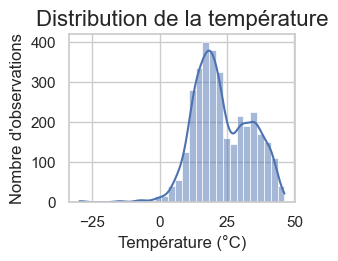

In [23]:
# 1. Distribution des températures
plt.subplot(2, 2, 1)
sns.histplot(df_cleaned["temperature"], bins=30, kde=True)
plt.title("Distribution de la température", fontsize=16)
plt.xlabel("Température (°C)", fontsize=12)
plt.ylabel("Nombre d'observations", fontsize=12)

Text(0, 0.5, "Nombre d'observations")

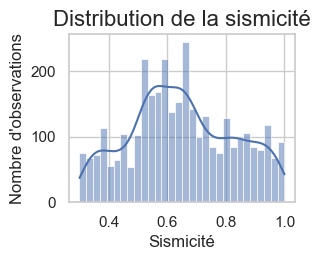

In [24]:
# 2. Distribution de la sismicité
plt.subplot(2, 2, 2)
sns.histplot(df_cleaned["sismicite"], bins=30, kde=True)
plt.title("Distribution de la sismicité", fontsize=16)
plt.xlabel("Sismicité", fontsize=12)
plt.ylabel("Nombre d'observations", fontsize=12)

Text(0, 0.5, 'Type de catastrophe')

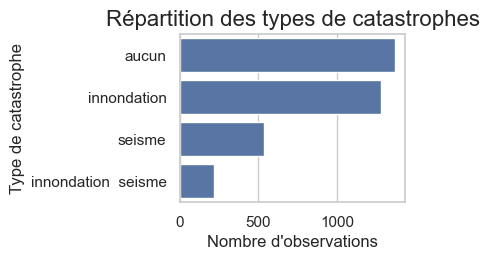

In [25]:
# 3. Répartition des catastrophes
plt.subplot(2, 2, 3)
sns.countplot(y="catastrophe", data=df_cleaned, order=df_cleaned["catastrophe"].value_counts().index)
plt.title("Répartition des types de catastrophes", fontsize=16)
plt.xlabel("Nombre d'observations", fontsize=12)
plt.ylabel("Type de catastrophe", fontsize=12)

Text(0, 0.5, 'Concentration de gaz (ppm)')

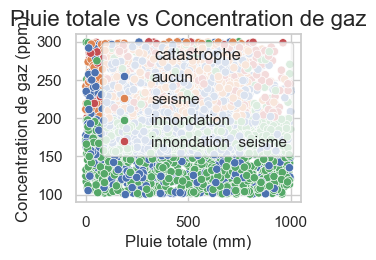

In [26]:
# 4. Corrélation pluie vs concentration gaz
plt.subplot(2, 2, 4)
sns.scatterplot(x="pluie_totale", y="concentration_gaz", hue="catastrophe", data=df_cleaned)
plt.title("Pluie totale vs Concentration de gaz", fontsize=16)
plt.xlabel("Pluie totale (mm)", fontsize=12)
plt.ylabel("Concentration de gaz (ppm)", fontsize=12)

Text(0, 0.5, 'Quartier')

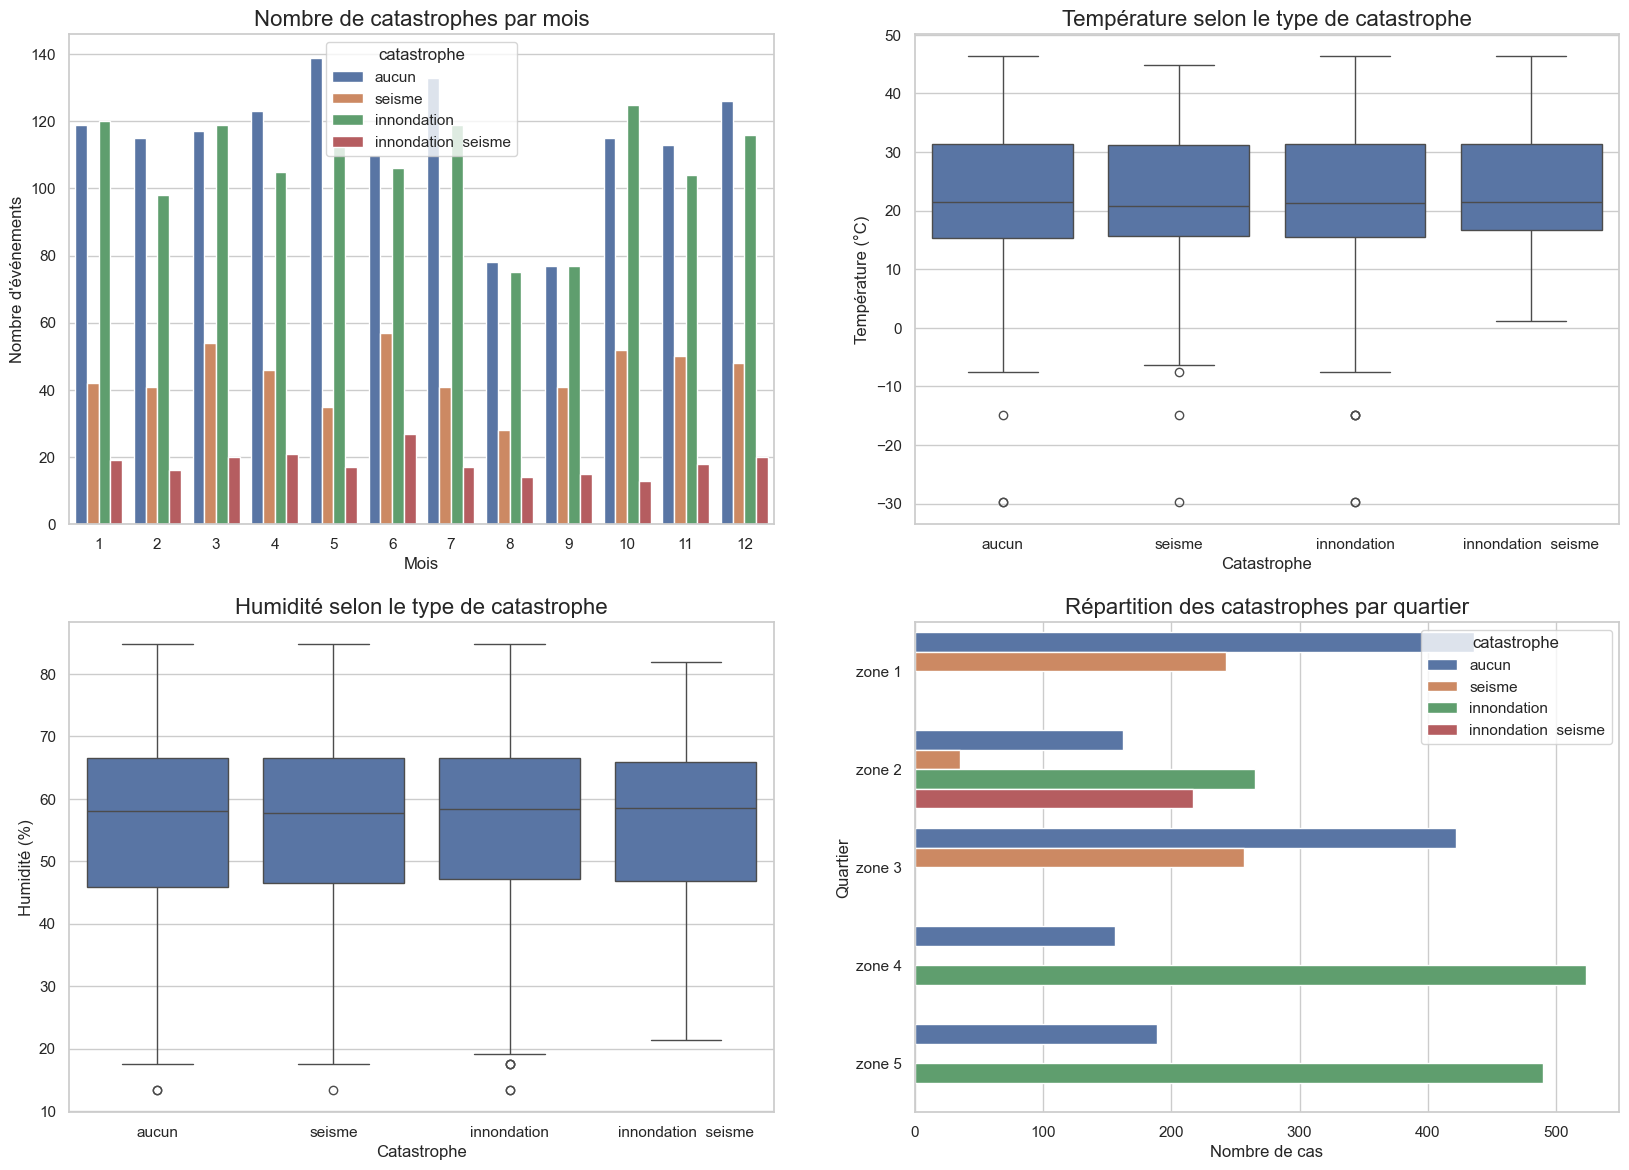

In [27]:

fig, axs = plt.subplots(2, 2, figsize=(20, 14))

# 1. Catastrophes par mois
sns.countplot(x="mois", hue="catastrophe", data=df_cleaned, ax=axs[0, 0])
axs[0, 0].set_title("Nombre de catastrophes par mois", fontsize=16)
axs[0, 0].set_xlabel("Mois")
axs[0, 0].set_ylabel("Nombre d'événements")

# 2. Température moyenne par type de catastrophe
sns.boxplot(x="catastrophe", y="temperature", data=df_cleaned, ax=axs[0, 1])
axs[0, 1].set_title("Température selon le type de catastrophe", fontsize=16)
axs[0, 1].set_xlabel("Catastrophe")
axs[0, 1].set_ylabel("Température (°C)")

# 3. Humidité moyenne par type de catastrophe
sns.boxplot(x="catastrophe", y="humidite", data=df_cleaned, ax=axs[1, 0])
axs[1, 0].set_title("Humidité selon le type de catastrophe", fontsize=16)
axs[1, 0].set_xlabel("Catastrophe")
axs[1, 0].set_ylabel("Humidité (%)")

# 4. Catastrophes par quartier
sns.countplot(y="quartier", hue="catastrophe", data=df_cleaned, order=df_cleaned["quartier"].value_counts().index, ax=axs[1, 1])
axs[1, 1].set_title("Répartition des catastrophes par quartier", fontsize=16)
axs[1, 1].set_xlabel("Nombre de cas")
axs[1, 1].set_ylabel("Quartier")


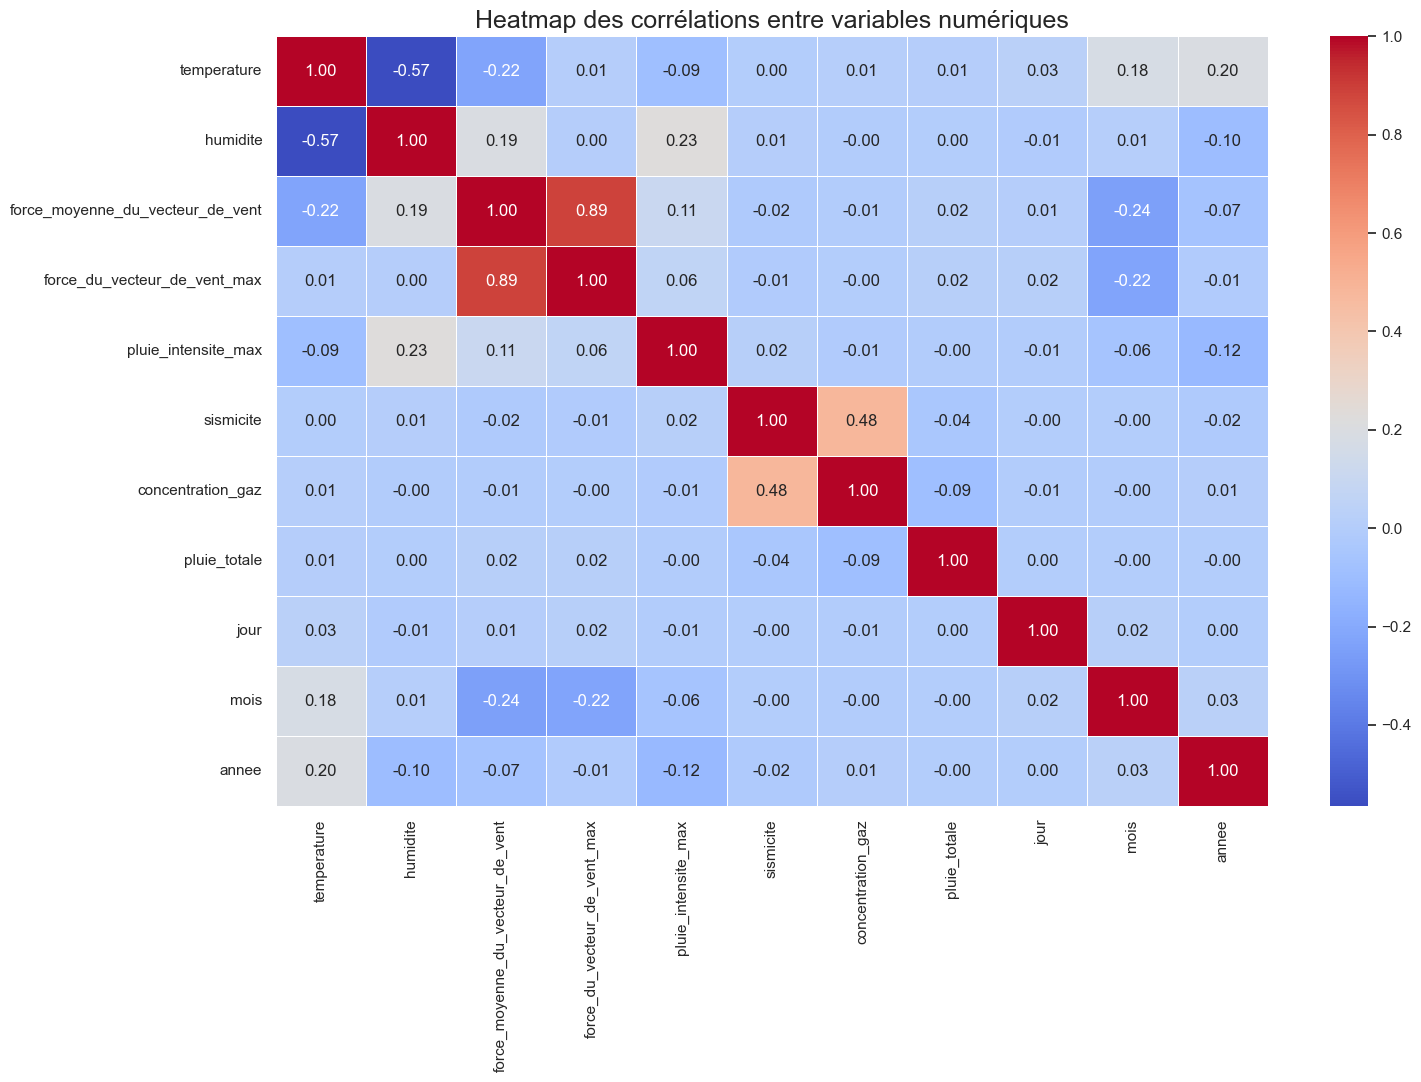

In [28]:
# Création d'une heatmap de corrélation visuelle
plt.figure(figsize=(16, 10))
corr = df_cleaned.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Heatmap des corrélations entre variables numériques", fontsize=18)
plt.show()

In [29]:
from sklearn.preprocessing import LabelEncoder

# Création d'un nouvel encodeur pour 'quartier'
le_quartier = LabelEncoder()

In [30]:
# Encodage de la colonne 'quartier'
df_cleaned["quartier_encoded"] = le_quartier.fit_transform(df_cleaned["quartier"])


In [31]:
df_cleaned

,temperature,humidite,force_moyenne_du_vecteur_de_vent,force_du_vecteur_de_vent_max,pluie_intensite_max,quartier,sismicite,concentration_gaz,pluie_totale,catastrophe,jour,mois,annee,quartier_encoded
0,5.7,75.6,3.8,4.3,0.0,zone 1,0.62,231.56,182.37,aucun,1,1,2170,0
1,5.7,75.6,3.8,4.3,0.0,zone 2,0.94,248.20,903.20,seisme,1,1,2170,1
2,5.7,75.6,3.8,4.3,0.0,zone 3,0.95,240.55,363.06,seisme,1,1,2170,2
3,5.7,75.6,3.8,4.3,0.0,zone 4,0.39,159.10,473.93,aucun,1,1,2170,3
4,5.7,75.6,3.8,4.3,0.0,zone 5,0.41,143.29,475.72,innondation,1,1,2170,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3390,27.4,46.8,3.8,6.3,0.0,zone 1,0.86,184.18,63.64,aucun,9,9,2171,0
3391,27.4,46.8,3.8,6.3,0.0,zone 2,0.74,227.11,874.81,innondation seisme,9,9,2171,1
3392,27.4,46.8,3.8,6.3,0.0,zone 3,0.53,204.04,668.92,aucun,9,9,2171,2
3393,27.4,46.8,3.8,6.3,0.0,zone 4,0.42,182.63,660.69,innondation,9,9,2171,3


In [32]:
# Création de l'encodeur pour la cible 'catastrophe'
le_catastrophe = LabelEncoder()

# Encodage de la colonne 'catastrophe'
df_cleaned["catastrophe_encoded"] = le_catastrophe.fit_transform(df_cleaned["catastrophe"])

# Affichage du mapping entre valeurs textuelles et encodées
cat_mapping = pd.DataFrame({
    "catastrophe": le_catastrophe.classes_,
    "catastrophe_encoded": le_catastrophe.transform(le_catastrophe.classes_)
})

In [33]:
cat_mapping

,catastrophe,catastrophe_encoded
0,aucun,0
1,innondation,1
2,innondation seisme,2
3,seisme,3


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE


In [35]:
features = [
    "temperature", "humidite", "pluie_totale", "pluie_intensite_max",
    "force_moyenne_du_vecteur_de_vent",  # ou "force_du_vecteur_de_vent_max"
    "sismicite", "concentration_gaz",
    "jour", "mois",  # optionnel : "annee"
    "quartier_encoded"
]

In [36]:
X = df_cleaned[features]
y = df_cleaned["catastrophe_encoded"]

In [37]:
# Split des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced']
}

In [39]:
# Lancer GridSearchCV
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='f1_weighted', n_jobs=-1)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced'],
                         'max_depth': [10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='f1_weighted')

In [40]:
# Meilleurs paramètres
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
best_params

{'class_weight': 'balanced',
 'max_depth': 10,
 'min_samples_leaf': 4,
 'min_samples_split': 10,
 'n_estimators': 200}

In [41]:
# Réentraîner le modèle avec les meilleurs paramètres
best_model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=4, min_samples_split=10,
                       n_estimators=200, random_state=42)

In [42]:
# Prédictions
y_pred_best = best_model.predict(X_test)

# Rapport de classification
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_best, target_names=le_catastrophe.classes_))


                     precision    recall  f1-score   support

              aucun       0.89      0.49      0.63       249
        innondation       0.76      0.93      0.84       276
innondation  seisme       0.57      1.00      0.73        40
             seisme       0.76      0.91      0.83       114

           accuracy                           0.77       679
          macro avg       0.75      0.83      0.76       679
       weighted avg       0.80      0.77      0.75       679



In [43]:
# # Créer et entraîner un modèle Random Forest
# model = RandomForestClassifier(n_estimators=100, random_state=42)
# model.fit(X_train, y_train)


In [44]:
# # Prédictions sur le jeu de test
# y_pred = model.predict(X_test)


In [45]:
# # Rapport de classification
# report = classification_report(y_test, y_pred, target_names=le_catastrophe.classes_, output_dict=False)
# print(report)


In [46]:
# # Matrice de confusion
# conf_mat = confusion_matrix(y_test, y_pred)

# # Afficher la matrice de confusion
# plt.figure(figsize=(8, 6))
# sns.heatmap(conf_mat, annot=True, fmt="d", xticklabels=le_catastrophe.classes_, yticklabels=le_catastrophe.classes_, cmap="Blues")
# plt.xlabel("Prédit")
# plt.ylabel("Réel")
# plt.title("Matrice de confusion - Modèle Random Forest")
# plt.show()

In [47]:
from xgboost import XGBClassifier

In [48]:
# Modèle XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)

c:\ProgramData\anaconda\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:24:23] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

In [49]:
# Prédiction
y_pred_xgb = xgb_model.predict(X_test)


In [50]:
# Rapport et matrice de confusion
report_xgb = classification_report(y_test, y_pred_xgb, target_names=le_catastrophe.classes_, output_dict=False)
conf_mat_xgb = confusion_matrix(y_test, y_pred_xgb)


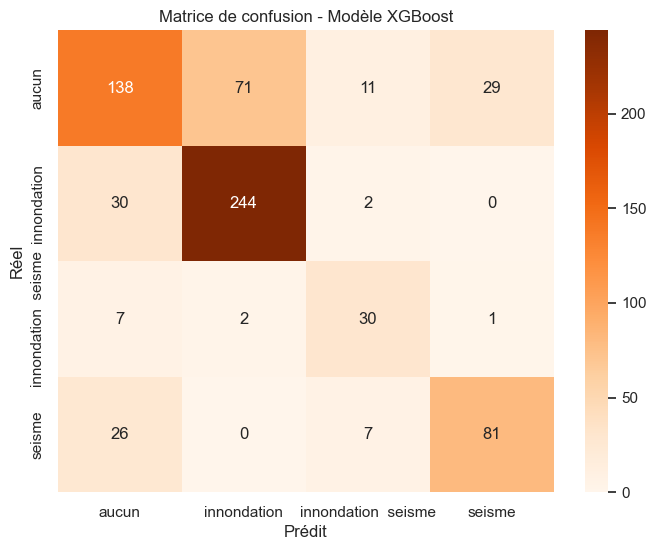

In [51]:
# Affichage de la matrice de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat_xgb, annot=True, fmt="d", xticklabels=le_catastrophe.classes_, yticklabels=le_catastrophe.classes_, cmap="Oranges")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion - Modèle XGBoost")
plt.show()

In [52]:
print(report_xgb)

                     precision    recall  f1-score   support

              aucun       0.69      0.55      0.61       249
        innondation       0.77      0.88      0.82       276
innondation  seisme       0.60      0.75      0.67        40
             seisme       0.73      0.71      0.72       114

           accuracy                           0.73       679
          macro avg       0.70      0.72      0.71       679
       weighted avg       0.72      0.73      0.72       679



In [53]:
import numpy as np

# Exemple de nouvelle observation (à adapter avec tes vraies valeurs)
nouvelle_donnee = {
    "temperature": 5.7,
    "humidite": 75.6,
    "pluie_totale": 182.37,
    "pluie_intensite_max": 0.0,
    "force_moyenne_du_vecteur_de_vent": 3.8,
    # "force_du_vecteur_de_vent_max": 4.3,
    "sismicite": 0.62,
    "concentration_gaz": 231.56,
    "jour": 1,
    "mois": 1,
    "quartier_encoded": 0  # Adapter le quartier
}

# Convertir en DataFrame avec les colonnes dans le bon ordre
X_nouvelle = pd.DataFrame([nouvelle_donnee])[features]

# Prédire
prediction_encoded = best_model.predict(X_nouvelle)[0]

# Décoder la prédiction
prediction_label = le_catastrophe.inverse_transform([prediction_encoded])[0]

print(f"✅ Catastrophe prédite : {prediction_label}")


✅ Catastrophe prédite : seisme


In [54]:
# Choisir une ligne dans le jeu de test (ex : la 0e)
ligne_test = X_test.iloc[[0]]  # avec [[]] pour garder le format DataFrame

# Prédiction du modèle
pred_encoded = best_model.predict(ligne_test)[0]

# Décoder la prédiction
pred_label = le_catastrophe.inverse_transform([pred_encoded])[0]

# Catégorie réelle
true_encoded = y_test.iloc[0]
true_label = le_catastrophe.inverse_transform([true_encoded])[0]

# Affichage
print(f"✅ Catastrophe prédite : {pred_label}")
print(f"🎯 Catastrophe réelle  : {true_label}")


✅ Catastrophe prédite : innondation  seisme
🎯 Catastrophe réelle  : aucun


In [55]:
# Évaluer les 10 premières lignes du test
for i in range(20):
    ligne = X_test.iloc[[i]]
    vrai = y_test.iloc[i]
    
    pred =  best_model.predict(ligne)[0]
    vrai_label = le_catastrophe.inverse_transform([vrai])[0]
    pred_label = le_catastrophe.inverse_transform([pred])[0]

    print(f"Ligne {i} → Prédit : {pred_label} | Réel : {vrai_label}")


Ligne 0 → Prédit : innondation  seisme | Réel : aucun
Ligne 1 → Prédit : innondation | Réel : aucun
Ligne 2 → Prédit : innondation | Réel : aucun
Ligne 3 → Prédit : seisme | Réel : seisme
Ligne 4 → Prédit : innondation | Réel : aucun
Ligne 5 → Prédit : innondation | Réel : innondation
Ligne 6 → Prédit : aucun | Réel : innondation
Ligne 7 → Prédit : innondation  seisme | Réel : seisme
Ligne 8 → Prédit : innondation | Réel : innondation
Ligne 9 → Prédit : innondation | Réel : innondation
Ligne 10 → Prédit : innondation | Réel : innondation
Ligne 11 → Prédit : innondation | Réel : innondation
Ligne 12 → Prédit : innondation | Réel : innondation
Ligne 13 → Prédit : innondation | Réel : innondation
Ligne 14 → Prédit : seisme | Réel : seisme
Ligne 15 → Prédit : innondation  seisme | Réel : innondation  seisme
Ligne 16 → Prédit : innondation | Réel : innondation
Ligne 17 → Prédit : innondation | Réel : innondation
Ligne 18 → Prédit : innondation | Réel : innondation
Ligne 19 → Prédit : aucun 

In [56]:
# import joblib

# # Supposons que ton modèle est dans une variable appelée 'model'
# joblib.dump(best_model, 'mon_model.pkl')

In [57]:
# Afficher les valeurs de la ligne 0 de X_test
print(X_test.iloc[1])

temperature                          26.20
humidite                             62.40
pluie_totale                        639.34
pluie_intensite_max                   0.00
force_moyenne_du_vecteur_de_vent      7.80
sismicite                             0.43
concentration_gaz                   133.24
jour                                  9.00
mois                                  5.00
quartier_encoded                      4.00
Name: 3354, dtype: float64
